In [14]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Dataset: PPG-DaLiA

Subjects: 15

Activities:
0 Transition
1 Sitting
2 Stairs
3 Table Soccer
4 Cycling
5 Driving
6 Lunch
7 Walking
8 Working

Sensors:

Wrist:
ACC
BVP
EDA
TEMP

Chest:
ACC
ECG
RESP

In [15]:
path = "/home/iailab42/g2-synthetic/PPG_FieldStudy/S1/S1.pkl"

with open(path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())

dict_keys(['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject'])


In [16]:
print("Subject:", data["subject"])
print(data["questionnaire"])
print("\nSignal groups:")
print(data["signal"].keys())

Subject: S1
{'WEIGHT': 78.0, 'Gender': ' m', 'AGE': 34, 'HEIGHT': 182.0, 'SKIN': 3, 'SPORT': 6}

Signal groups:
dict_keys(['chest', 'wrist'])


In [17]:
for k,v in data["signal"]["wrist"].items():
    print(k, np.array(v).shape)

print("========")

for k,v in data["signal"]["chest"].items():
    print(k, np.array(v).shape)

ACC (294784, 3)
BVP (589568, 1)
EDA (36848, 1)
TEMP (36848, 1)
ACC (6448400, 3)
ECG (6448400, 1)
EMG (6448400, 1)
EDA (6448400, 1)
Temp (6448400, 1)
Resp (6448400, 1)


In [18]:
print("Wrist sensors:")
for key in data["signal"]["wrist"].keys():
    print("-", key)

Wrist sensors:
- ACC
- BVP
- EDA
- TEMP


In [19]:
for key, value in data["signal"]["wrist"].items():
    print(key, np.array(value).shape)

ACC (294784, 3)
BVP (589568, 1)
EDA (36848, 1)
TEMP (36848, 1)


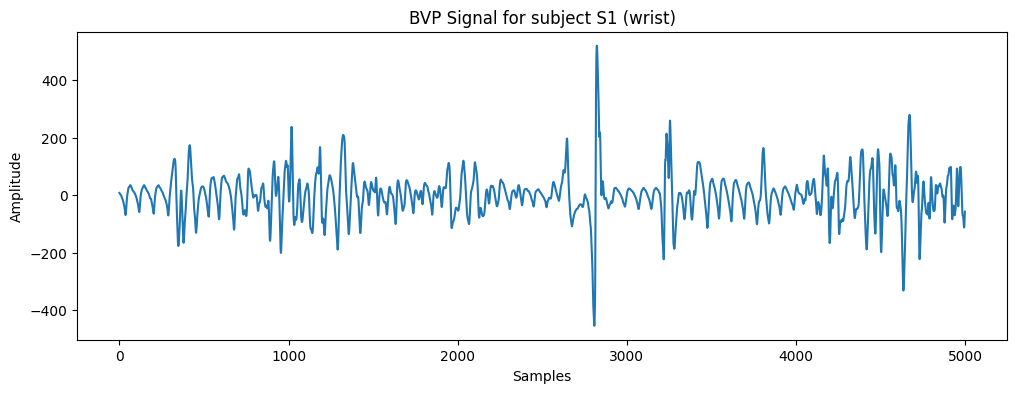

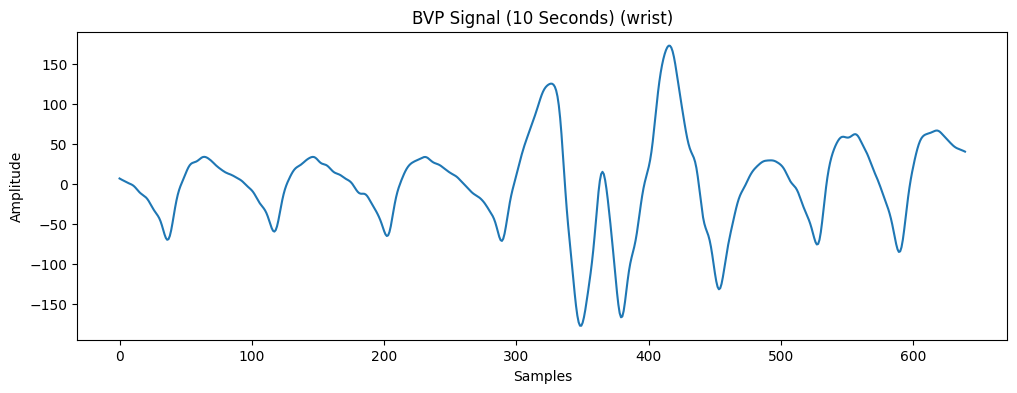

In [27]:
#BVP Plot

bvp = data["signal"]["wrist"]["BVP"]

plt.figure(figsize=(12, 4))
plt.plot(bvp[:5000])  # Plot the first 5000 samples
plt.title("BVP Signal for subject S1 (wrist)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(bvp[:640])   # first 10 seconds
plt.title("BVP Signal (10 Seconds) (wrist)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

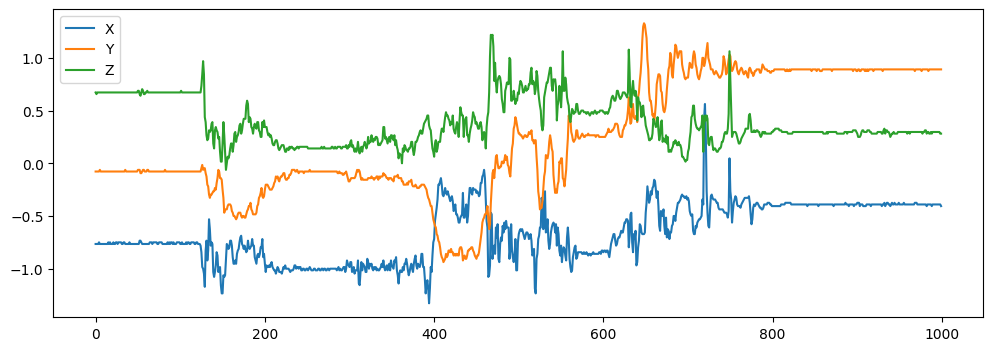

In [21]:
acc = data["signal"]["wrist"]["ACC"]

plt.figure(figsize=(12,4))

plt.plot(acc[:1000,0], label="X")
plt.plot(acc[:1000,1], label="Y")
plt.plot(acc[:1000,2], label="Z")

plt.legend()

plt.show()

In [22]:
activity = data["activity"]

print(activity.shape)
print(np.unique(activity))

(36848, 1)
[0. 1. 2. 3. 4. 5. 6. 7. 8.]


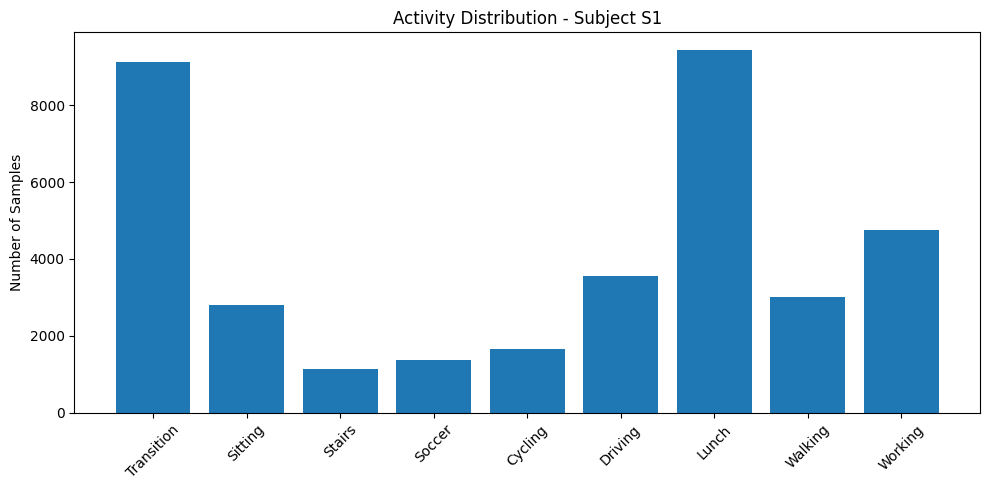

In [23]:
activity_names = {
    0: "Transition",
    1: "Sitting",
    2: "Stairs",
    3: "Soccer",
    4: "Cycling",
    5: "Driving",
    6: "Lunch",
    7: "Walking",
    8: "Working"
}

activity_flat = activity.flatten()

counts = pd.Series(activity_flat).value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(
    [activity_names[i] for i in counts.index],
    counts.values
)
plt.xticks(rotation=45)
plt.ylabel("Number of Samples")
plt.title("Activity Distribution - Subject S1")
plt.tight_layout()
plt.show()

In [24]:
df = pd.DataFrame({
    "ACC_X": acc[:1000,0],
    "ACC_Y": acc[:1000,1],
    "ACC_Z": acc[:1000,2],
})

df.corr()

,ACC_X,ACC_Y,ACC_Z
ACC_X,1.000000,0.524490,-0.035068
ACC_Y,0.524490,1.000000,-0.142204
ACC_Z,-0.035068,-0.142204,1.000000


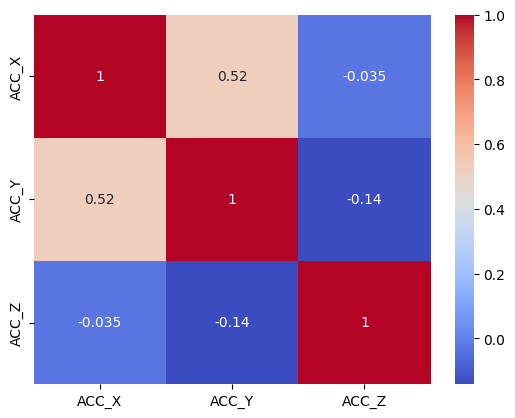

In [25]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

In [26]:
window_size = 512

window = bvp[:window_size]

print("Window shape:", window.shape)

Window shape: (512, 1)


64 Hz x 8 s = 512  samples
